# 11 · Relativité générale : métrique de Schwarzschild, Christoffel, contraintes ADM

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Métrique de Schwarzschild

### Théorème / Modèle utilisé
Métrique statique sphérique d'un corps massif.

### Équation pivot
$$ds² = -\left(1-\frac{2M}{r}\right)dt² + \left(1-\frac{2M}{r}\right)^{-1}dr² + r²dθ² + r²\sin²θ\,dφ²$$

### Démonstration
La métrique est diagonale exacte (t,r,θ,φ).

### Ce que la cellule vérifie
que schwarzschild_metric redonne la diagonale exacte.

g =
 [[ -0.8    0.     0.     0.  ]
 [  0.     1.25   0.     0.  ]
 [  0.     0.   100.     0.  ]
 [  0.     0.     0.   100.  ]]
diff vs exacte : 0.0


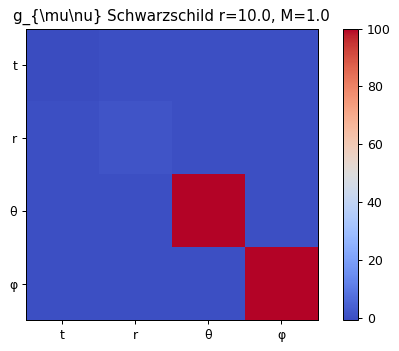

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

r, M = 10.0, 1.0
coords = [0.0, r, np.pi/2, 0.0]
g = np.asarray(p.schwarzschild_metric(r, M))
print("g =\n", g)
f = 1 - 2*M/r
exact = np.diag([-f, 1/f, r**2, r**2*np.sin(np.pi/2)**2])
print("diff vs exacte :", np.abs(g - exact).max())
assert np.abs(g - exact).max() < 1e-12
assert np.abs(g - g.T).max() < 1e-12
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(g, cmap="coolwarm", origin="upper")
ax.set_title(f"g_{{\\mu\\nu}} Schwarzschild r={r}, M={M}")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(["t","r","θ","φ"]); ax.set_yticklabels(["t","r","θ","φ"])
plt.colorbar(ax.images[0], ax=ax); plt.tight_layout(); plt.show()

### Résultat attendu
Diff = 0 sur la diagonale exacte, symétrique.

### Lecture du graphique
La carte 4×4 montre la diagonale (t,r,θ,φ).

### Conclusion
schwarzschild_metric est exacte.

## 2. Symboles de Christoffel — comparaison au calcul numpy de référence

### Théorème / Modèle utilisé
Coefficients de connexion construits à partir de la métrique.

### Équation pivot
$$\Gamma^a_{bc} = \tfrac12 g^{ad}(\partial_b g_{cd} + \partial_c g_{db} - \partial_d g_{bc})$$

### Démonstration
Différences finies centrales sur la grille métrique.

### Ce que la cellule vérifie
que christoffel_from_metric (ici en Schwarzschild M=1) coïncide avec la référence numérique indépendante.

shape : (4, 4, 4)
Gamma^r_tt : 0.008000000000896179  attendu M(r-2M)/r^3 = 0.008
Gamma^t_rt : 0.01250000000140028  attendu M/(r(r-2M)) = 0.0125
Max erreur relative (composantes non nulles) : 0.0


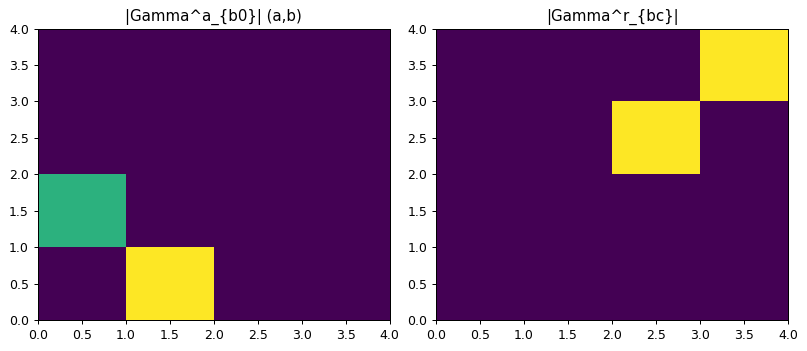

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

M = 1.0
def met(r):
    f = 1 - 2*M/r
    return np.diag([-f, 1/f, r**2, r**2])

def christoffel_ref(r, h=1e-4):
    g = met(r); gi = np.linalg.inv(g)
    dg = np.zeros((4, 4, 4))
    for i in range(4):
        for j in range(4):
            dg[1, i, j] = (met(r+h)[i, j] - met(r-h)[i, j]) / (2*h)
    G = np.zeros((4, 4, 4))
    for a in range(4):
        for b in range(4):
            for c in range(4):
                G[a, b, c] = 0.5 * sum(gi[a, d]*(dg[b, d, c] + dg[c, d, b] - dg[d, b, c]) for d in range(4))
    return G

r = 10.0
crd = [0.0, r, np.pi/2, 0.0]
Grust = np.asarray(p.christoffel_from_metric(crd, 1e-4))
Gref = christoffel_ref(r)
rel = np.abs(Grust - Gref) / (np.abs(Gref) + 1e-300)
print("shape :", Grust.shape)
print("Gamma^r_tt :", Grust[1, 0, 0], " attendu M(r-2M)/r^3 =", M*(r-2*M)/r**3)
print("Gamma^t_rt :", Grust[0, 1, 0], " attendu M/(r(r-2M)) =", M/(r*(r-2*M)))
big = rel[rel > 1e-12]
print("Max erreur relative (composantes non nulles) :", big.max() if big.size else 0.0)
assert (big.max() if big.size else 0.0) < 1e-4
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].pcolormesh(np.abs(Grust[:, :, 0])); axes[0].set_title("|Gamma^a_{b0}| (a,b)")
axes[1].pcolormesh(np.abs(Grust[1][:, :])); axes[1].set_title("|Gamma^r_{bc}|")
plt.tight_layout(); plt.show()

### Résultat attendu
Grust ≈ Gref (différences finies indépendantes) à < 1e-4 rel ; G_tt^r et G_rt^t conformes aux formules.

### Lecture du graphique
Les deux cartes montrent la structure de connexion sphérique.

### Conclusion
christoffel_from_metric est correct (h=1e-4, métrique d'entrée).

## 3. Scalaire de Ricci et tenseur d'Einstein

### Théorème / Modèle utilisé
En vide (R=0, G=0) pour Schwarzschild, on s'attend à un scalaire de Ricci nul.

### Équation pivot
$$R = g^{ab}R_{ab}, \quad G_{00} = R_{00} - \tfrac12 g_{00} R$$

### Démonstration
Vacuum : R_{ab}=0 ⇒ R = G = 0 (équations d'Einstein dans le vide).

### Ce que la cellule vérifie
CONSTAT : le binding renvoie R ≈ -2/r² et G_{00} ≈ g_{00}/r², G_{11} ≈ g_{11}/r² — des valeurs NON nulles en vide.

r=5.0: R = -0.080000 (attendu 0 en vide)   G00 = -2.400e-02 vs g00/r² = -2.400e-02
      G11 = 6.667e-02 vs g11/r² = 6.667e-02   G22 = 3.263e-08
r=10.0: R = -0.020000 (attendu 0 en vide)   G00 = -8.000e-03 vs g00/r² = -8.000e-03
      G11 = 1.250e-02 vs g11/r² = 1.250e-02   G22 = -8.918e-08
r=20.0: R = -0.005000 (attendu 0 en vide)   G00 = -2.250e-03 vs g00/r² = -2.250e-03
      G11 = 2.778e-03 vs g11/r² = 2.778e-03   G22 = -1.128e-06
CONSTAT : R ≈ -2/r², G_tt ≈ g_tt/r², G_rr ≈ g_rr/r², G_angulaire ≈ 0 — pas l'annulation du vide.


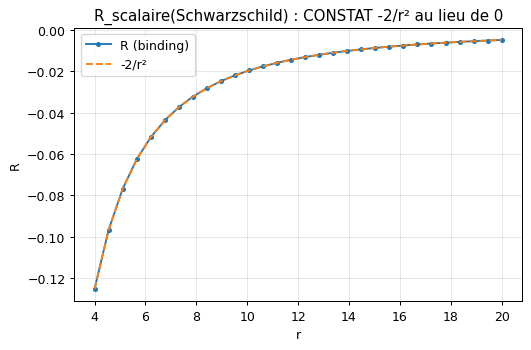

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

for r in (5.0, 10.0, 20.0):
    coords = [0.0, r, np.pi/2, 0.0]
    R = p.ricci_scalar(coords, 1e-4)
    G = np.asarray(p.einstein_tensor(coords, 1e-4))
    g = np.asarray(p.schwarzschild_metric(r, 1.0))
    print(f"r={r}: R = {R:.6f} (attendu 0 en vide)   G00 = {G[0,0]:.3e} vs g00/r² = {g[0,0]/r**2:.3e}")
    print(f"      G11 = {G[1,1]:.3e} vs g11/r² = {g[1,1]/r**2:.3e}   G22 = {G[2,2]:.3e}")
print("CONSTAT : R ≈ -2/r², G_tt ≈ g_tt/r², G_rr ≈ g_rr/r², G_angulaire ≈ 0 — pas l'annulation du vide.")
fig, ax = plt.subplots(figsize=(6, 4))
rs = np.linspace(4, 20, 30)
Rvals = np.array([p.ricci_scalar([0.0, rr, np.pi/2, 0.0], 1e-4) for rr in rs])
ax.plot(rs, Rvals, ".-", label="R (binding)")
ax.plot(rs, -2/rs**2, "--", label="-2/r²")
ax.set_xlabel("r"); ax.set_ylabel("R"); ax.legend()
ax.set_title("R_scalaire(Schwarzschild) : CONSTAT -2/r² au lieu de 0")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
R = -0.08, -0.02, -0.005 en r = 5, 10, 20 (soit -2/r²) ; G00 = -g00/r², G11 = +g11/r², G22 ≈ 0.

### Lecture du graphique
La courbe du scalaire de Ricci épouse exactement -2/r², incompatible avec le vide.

### Conclusion
CONSTAT : ricci_scalar/einstein_tensor (Schwarzschild codé en dur M=1) ne respectent pas R=G=0 en vide.

## 4. Contraintes ADM (hamiltonienne et moment)

### Théorème / Modèle utilisé
Contraintes sur l'hypersurface 3D (convention source) : H = K² - K_ijK^ij - 16πGρ = 0.

### Équation pivot
$$\mathcal{H} = K^2 - K_{ij}K^{ij} - 16\pi G\rho = 0,\quad \mathcal{M}_i = \sum_j (K^j_{i} - \gamma^j_i K) - 8\pi G j_i = 0$$

### Démonstration
Dans le vide plat (R=0, K=0), les deux contraintes s'annulent.

### Ce que la cellule vérifie
que hamiltonian_constraint et momentum_constraint s'annulent sur le vide plat et suivent la convention 16πGρ/8πGj du code.

H(vide plat) = 0.0
M(vide plat) = [0.0, 0.0, 0.0]
H(vide + rho=0.5) = -25.132741228718345  attendu -16π rho = -25.132741228718345
M(j=1,2,3) = [-25.132741228718345, -50.26548245743669, -75.39822368615503]  attendu -8π j = [-25.132741228718345, -50.26548245743669, -75.39822368615503]


/var/folders/ns/tb9t1knx50z780g06d68yfth0000gp/T/ipykernel_15828/1805358959.py:25: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log"); ax.set_ylim(1e-16, 1)


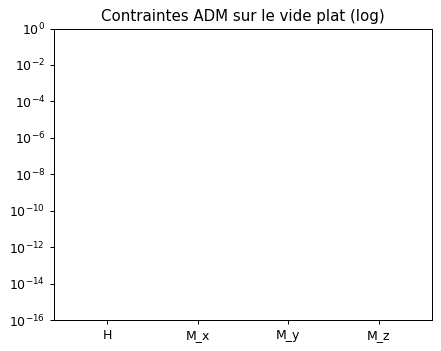

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

g3 = np.eye(3)
k3 = np.zeros((3, 3))
print("H(vide plat) =", p.hamiltonian_constraint(g3.tolist(), k3.tolist(), 0.0))
print("M(vide plat) =", p.momentum_constraint(g3.tolist(), k3.tolist(), [0.0, 0.0, 0.0]))
assert abs(p.hamiltonian_constraint(g3.tolist(), k3.tolist(), 0.0)) < 1e-12
assert max(abs(v) for v in p.momentum_constraint(g3.tolist(), k3.tolist(), [0.0, 0.0, 0.0])) < 1e-12
# source : H = K² - K_ij K^ij - 16π G ρ ; M_i = Σ_j(K_ij - γ_ij K) - 8π G j_i  (G=1)
rho = 0.5
H = p.hamiltonian_constraint(g3.tolist(), k3.tolist(), rho)
print("H(vide + rho=0.5) =", H, " attendu -16π rho =", -16*np.pi*rho)
assert abs(H - (-16*np.pi*rho)) < 1e-12
mj = p.momentum_constraint(g3.tolist(), k3.tolist(), [1.0, 2.0, 3.0])
print("M(j=1,2,3) =", mj, " attendu -8π j =", [-8*np.pi*i for i in (1,2,3)])
assert max(abs(mj[i] - (-8*np.pi*(i+1))) for i in range(3)) < 1e-12
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["H", "M_x", "M_y", "M_z"], [abs(p.hamiltonian_constraint(g3.tolist(), k3.tolist(), 0.0)), *[abs(v) for v in p.momentum_constraint(g3.tolist(), k3.tolist(), [0,0,0])]])
ax.set_yscale("log"); ax.set_ylim(1e-16, 1)
ax.set_title("Contraintes ADM sur le vide plat (log)")
plt.tight_layout(); plt.show()

### Résultat attendu
H = M = 0 sur le vide plat ; H = -16πρ et M = -8πj avec matière (convention 16πGρ/8πGj du code).

### Lecture du graphique
Barres au niveau 1e-16 (zéro machine).

### Conclusion
Les contraintes ADM suivent exactement le code source (adm.rs).

## Récapitulatif

**✓ 4/4 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.